In [16]:
from copy import deepcopy
import h5py
import numpy as np
import scipy as sp
from scipy.sparse.linalg import norm
import matplotlib.pyplot as plt
import openfermion as of
from openfermionpyscf import run_pyscf
import qiskit
from quimb_tebd import (
    pauli_sum_to_mpo, get_drmg_ground_state, trotter_circuit_from_psum,
    energy_vs_d, get_evolved_states, fill_subspace_matrices_mps,
    exact_evolved_states, mps_to_vector, fill_subspace_matrices_vectors
)

In [17]:
molec = "BeH2"
basis = "sto-3g"
n_elec = 6
geometry = of.chem.geometry_from_pubchem(molec)
multiplicity = 1
dmrg_max_bond = [12, 14, 16]
tebd_max_bond = deepcopy(dmrg_max_bond)
mpo_max_bond = 500
steps = 10
eps = 1e-12
d = 20

In [18]:
# Get the Hamiltonian.
molecule = of.chem.MolecularData(
    geometry, basis, multiplicity
)
molecule = run_pyscf(molecule, run_scf=1, run_fci=1)
print(f"HF energy:", molecule.hf_energy)
print(f"FCI energy:", molecule.fci_energy)
hamiltonian = molecule.get_molecular_hamiltonian()
hamiltonian_qubop = of.transforms.jordan_wigner(hamiltonian)
hamiltonian_psum = of.transforms.qubit_operator_to_pauli_sum(hamiltonian_qubop)
ham_sparse = of.linalg.get_sparse_operator(hamiltonian_qubop)
qs = hamiltonian_psum.qubits
hamiltonian_mpo = pauli_sum_to_mpo(hamiltonian_psum, qs, mpo_max_bond)

HF energy: -14.443241148489246
FCI energy: -14.472947415601425


In [19]:
ham_norm = norm(ham_sparse)
tau = 10. * np.pi / ham_norm
print(f"tau = {tau:4.5e}")

tau = 3.21087e-02


In [20]:
# Run DMRG
ground_states = []
dmrg_energies = []
for i, chi_dmrg in enumerate(dmrg_max_bond):
    ground_state, energy, number = get_drmg_ground_state(hamiltonian_mpo, n_elec, chi_dmrg)
    ground_states.append(ground_state.copy())
    dmrg_energies.append(energy)
    print(f"DMRG ground state has energy {energy} and occupation {number}.")

DMRG ground state has energy -14.25312942047468 and occupation 6.000001052210372.
DMRG ground state has energy -14.305450623180777 and occupation 6.000000000969408.
DMRG ground state has energy -14.253298197129624 and occupation 5.9999991629616805.


In [23]:
ev_circuit = trotter_circuit_from_psum(hamiltonian_psum, tau, steps)
ev_circuit_transpiled = qiskit.transpile(ev_circuit, basis_gates=["u3", "cx"])

krylov_energies = np.zeros((len(tebd_max_bond), d-1), dtype=float)
krylov_num_kept = np.zeros((len(tebd_max_bond), d-1), dtype=float)
ref_state = ground_states[0].copy()
for i, chi_tebd in enumerate(tebd_max_bond):
    print(f"chi = {chi_tebd}")
    states = get_evolved_states(ev_circuit_transpiled, ref_state, d, chi_tebd, None)
    h, s = fill_subspace_matrices_mps(states, hamiltonian_mpo)
    energies, num_kept = energy_vs_d(h, s, method="threshold", eps=eps)
    krylov_energies[i, :] = deepcopy(energies)
    krylov_num_kept[i, :] = deepcopy(num_kept)

chi = 12
chi = 14


/Users/benjamindalfavero/.venv/tdvp/lib/python3.13/site-packages/quimb/tensor/decomp.py:363: UserWarning: Got: Internal algorithm failed to converge., falling back to scipy gesvd driver.
  warnings.warn(f"Got: {e}, falling back to scipy gesvd driver.")


chi = 16


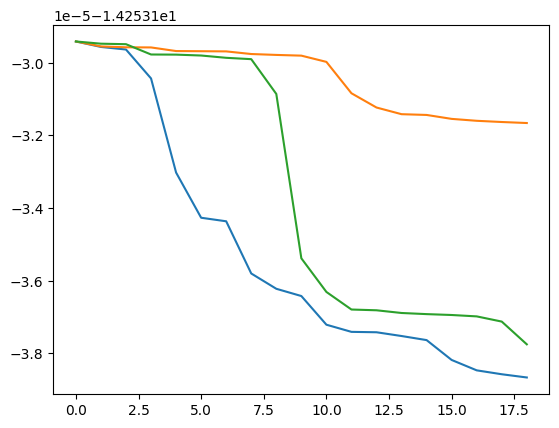

In [24]:
fig, ax = plt.subplots()
for i, chi_tebd in enumerate(tebd_max_bond):
    ax.plot(krylov_energies[i, :], label=f"TEBD chi = {chi_tebd}")